In [25]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from gstools import SRF, Gaussian
from gstools.random import MasterRNG

In [26]:
mx = 16
mt = 51
n = 110
x_range = 1
y_range = 10

In [27]:
x = np.linspace(0, x_range, mx)
y = np.linspace(0, y_range, mt)

In [28]:
seed = MasterRNG(123)

In [29]:
def one_function(x):
    model = Gaussian(dim=1, var=50, len_scale=0.6)
    srf = SRF(model, seed=seed())
    f = srf.structured([x])
    return f

In [30]:
U_in = np.zeros((mx, n))
U = np.zeros((mx, mt, n))

for nn in range(n):
    x_values = one_function(x)
    U_in[:,nn] = x_values
    for tt in range(mt):
        U[:,tt,nn] = x_values

(16, 51)
(16, 51)


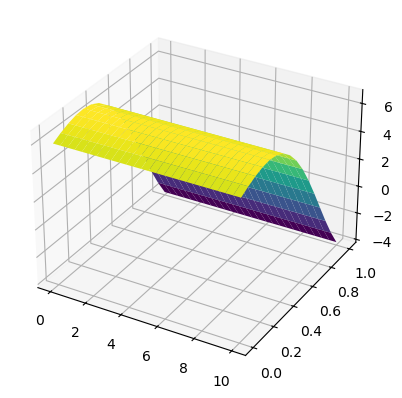

In [31]:
X, Y = np.meshgrid(y, x)
print(X.shape)
print(Y.shape)
fig = plt.figure()
ax = fig.add_subplot(111, projection = '3d')
ax.plot_surface(X, Y, U[:,:,10], cmap = 'viridis' )

In [32]:
print(U.shape)

(16, 51, 110)


In [33]:
S = np.zeros((mx, mt, n))
S = U
dx = abs(x[0]-x[1])
dt = abs(y[0]-y[1])
alpha = 0.01

for d in range(n):
    for t in range(1, mt-1):
        for i in range(1, mx-1):
            S[i, t+1, d] = U[i, t, d] + alpha * (U[i+1, t, d]-2*U[i,t,d]+U[i-1,t,d]) * (dt / dx ** 2)

(16, 51)
(16, 51)


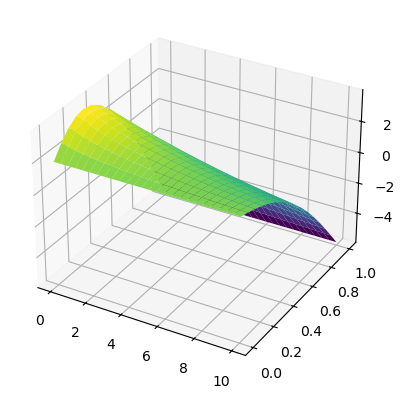

In [34]:
X, Y = np.meshgrid(y, x)
print(X.shape)
print(Y.shape)
fig = plt.figure()
ax = fig.add_subplot(111, projection = '3d')
ax.plot_surface(X, Y, S[:,:,81], cmap = 'viridis' )

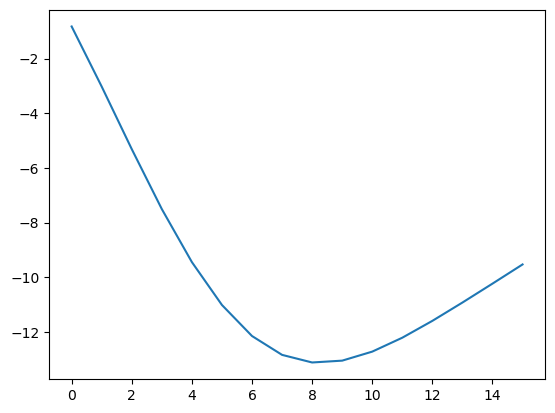

In [35]:
plt.plot(U_in[:, 1])

In [36]:
x.shape, y.shape, S.shape, U_in.shape

((16,), (51,), (16, 51, 110), (16, 110))

In [37]:
combinations = []

for i in range(len(x)):
    for j in range(len(y)):
        combinations.append((x[i], y[j]))

combinations = np.array(combinations)
print(combinations.shape)
print(combinations)

(816, 2)
[[ 0.   0. ]
 [ 0.   0.2]
 [ 0.   0.4]
 ...
 [ 1.   9.6]
 [ 1.   9.8]
 [ 1.  10. ]]


In [79]:
x = combinations

In [38]:
x_space = np.linspace(0, x_range, mx)
y_space = np.linspace(0, y_range, mt)

In [39]:
def integrate_dataset(mx=mx, mt=mt, n=n, x=x, U_in=U_in, U=U, S=S):
    us = np.zeros((mx*mt*n, mx))
    xs = np.zeros((mx*mt*n, 2))
    ss = np.zeros((mx*mt*n, 1))
    count = 0
    for i in range(n):
        for j in range(mx):
            for jj in range(mt):
                us[count,:] = U_in[:,i]
                xs[count] = [x_space[j], y_space[jj]]
                ss[count] = S[j, jj, i]
                count = count + 1

    return us, xs, ss

In [40]:
us, xs, ss = integrate_dataset()

In [41]:
us.shape, xs.shape, ss.shape

((89760, 16), (89760, 2), (89760, 1))

In [42]:
import torch.nn as nn
def batch_dataset(batch_size, mx=mx, mt=mt, n=n, x=x, U=U, S=S, ratio=0.8):
    us, xs, ss = integrate_dataset(mx, mt, n, x, U_in, U, S)

    train_size = int(len(us)*ratio )
    us_train = us[:train_size]
    xs_train = xs[:train_size]
    ss_train = ss[:train_size]

    us_test = us[:train_size:]
    xs_test = xs[:train_size:]
    ss_test = ss[:train_size:]

    us_train = torch.tensor(us_train, dtype=torch.float32)
    xs_train = torch.tensor(xs_train, dtype=torch.float32)
    ss_train = torch.tensor(ss_train, dtype=torch.float32)

    train_dataset = torch.utils.data.TensorDataset(us_train, xs_train, ss_train)
    train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    us_test = torch.tensor(us_test, dtype=torch.float32)
    xs_test = torch.tensor(xs_test, dtype=torch.float32)
    ss_test = torch.tensor(ss_test, dtype=torch.float32)

    test_dataset = torch.utils.data.TensorDataset(us_test, xs_test, ss_test)
    test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

    return train_dataloader, test_dataloader

In [43]:
train_data, test_data = batch_dataset(batch_size=32, mx=mx, mt=mt, n=n, x=x, U=U, S=S, ratio=0.8)

In [44]:
for u_in_, x_, s_ in train_data:
    print(u_in_.shape, x_.shape, s_.shape)
    break

torch.Size([32, 16]) torch.Size([32, 2]) torch.Size([32, 1])


In [51]:
import torch.nn as nn

class DeepONet(nn.Module):
    def __init__(self, neurons=40, in1 = mx, in2= 2, output_neurons =20):
        super(DeepONet, self).__init__()
        self.neurons = neurons
        self.duble_neurons = 2*neurons
        self.in1 = in1
        self.in2 = in2
        self.output_neurons = output_neurons
        self.branch = self.branch_network()
        self.trunk = self.trunk_network()
        
    def branch_network(self):
        branch = nn.Sequential(
            nn.Linear(self.in1,self.duble_neurons),
            nn.ReLU(),
            nn.Linear(self.duble_neurons,self.neurons),
            nn.ReLU(),
            nn.Linear(self.neurons,self.output_neurons),
        )
        return branch
        
    def trunk_network(self):
        trunk=nn.Sequential(
            nn.Linear(self.in2,self.neurons),
            nn.ReLU(),
            nn.Linear(self.neurons,self.neurons),
            nn.ReLU(),
            nn.Linear(self.neurons,self.neurons),
            nn.ReLU(),
            nn.Linear(self.neurons,self.output_neurons),
        )
        return trunk
        
    def forward(self, x1, x2):
        x1 = self.branch(x1)
        x2 = self.trunk(x2)
        x = torch.einsum("bi, bi->b", x1,x2)
        x = torch.unsqueeze(x,1)
        return x

In [54]:
model = DeepONet(neurons=40, in1 = mx, in2= 2, output_neurons =20)

In [55]:
model

DeepONet(
  (branch): Sequential(
    (0): Linear(in_features=16, out_features=80, bias=True)
    (1): ReLU()
    (2): Linear(in_features=80, out_features=40, bias=True)
    (3): ReLU()
    (4): Linear(in_features=40, out_features=20, bias=True)
  )
  (trunk): Sequential(
    (0): Linear(in_features=2, out_features=40, bias=True)
    (1): ReLU()
    (2): Linear(in_features=40, out_features=40, bias=True)
    (3): ReLU()
    (4): Linear(in_features=40, out_features=40, bias=True)
    (5): ReLU()
    (6): Linear(in_features=40, out_features=20, bias=True)
  )
)

In [56]:
def loss(y_pred, y):
    return torch.mean((y_pred-y)**2)

In [57]:
#optimizer = torch.optim.LBFGS(model.parameters(), lr=0.001)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [58]:
train_losses = []

def closure():
    optimizer.zero_grad()
    l_total = 0

    for u_, x_, s_ in train_data:
        model.train()
        y_pred = model(u_, x_)
        l = loss(y_pred, s_)
        l_total += l.item()
        l.backward()

    l_total = l_total/ len(train_data)
    train_losses.append(l_total)

    return l_total

epochs = 600
for i in range(epochs):
    optimizer.step(closure)

    if i%20 == 0:
        print("Epoch", i, " / ", epochs, "loss ", train_losses[-1])



Epoch 0  /  600 loss  47.526671841395306
Epoch 20  /  600 loss  16.307813620822316
Epoch 40  /  600 loss  10.85299537377349
Epoch 60  /  600 loss  10.246374437728242
Epoch 80  /  600 loss  9.607717800055383
Epoch 100  /  600 loss  4.782890251188567
Epoch 120  /  600 loss  1.2916977192522583
Epoch 140  /  600 loss  1.1436672096344875
Epoch 160  /  600 loss  1.031739952431165
Epoch 180  /  600 loss  0.9436636408342716
Epoch 200  /  600 loss  0.8660597432862948
Epoch 220  /  600 loss  0.8027812750966897
Epoch 240  /  600 loss  0.7524439305956883
Epoch 260  /  600 loss  0.7047475062496629
Epoch 280  /  600 loss  0.6477314859907576
Epoch 300  /  600 loss  0.5608035298512581
Epoch 320  /  600 loss  0.4304617630673071
Epoch 340  /  600 loss  0.2714860313331273
Epoch 360  /  600 loss  0.163525750326846
Epoch 380  /  600 loss  0.11939570691715427
Epoch 400  /  600 loss  0.09946397644651925
Epoch 420  /  600 loss  0.08795384126723663
Epoch 440  /  600 loss  0.08090830746284436
Epoch 460  /  600 

Text(0, 0.5, 'Loss')

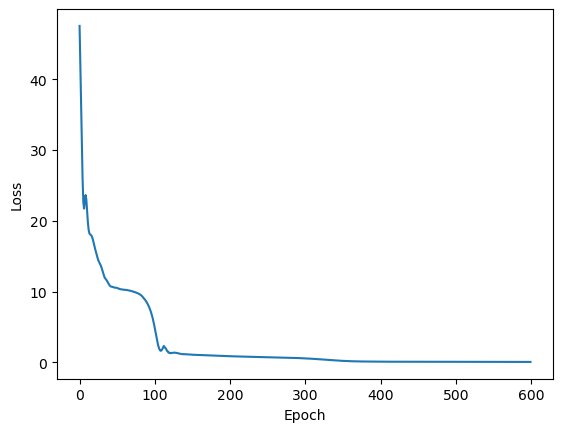

In [61]:
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")

In [62]:
mx = 16
mt = 51
n = 110
x_range = 1
y_range = 10

In [63]:
x_gen = np.linspace(0, x_range, mx)
y_gen = np.linspace(0, y_range, mt)

In [64]:
seed = MasterRNG(321)
def one_function(x):
    model = Gaussian(dim=1, var=50, len_scale=0.6)
    srf = SRF(model, seed=seed())
    f = srf.structured([x])
    return f

In [65]:
UU_in = np.zeros((mx, n))
UU = np.zeros((mx, mt, n))

for nn in range(n):
    x_values = one_function(x_gen)
    UU_in[:,nn] = x_values
    for tt in range(mt):
        UU[:,tt,nn] = x_values

In [80]:
target_result = 6
U_gen = UU_in[:,target_result]

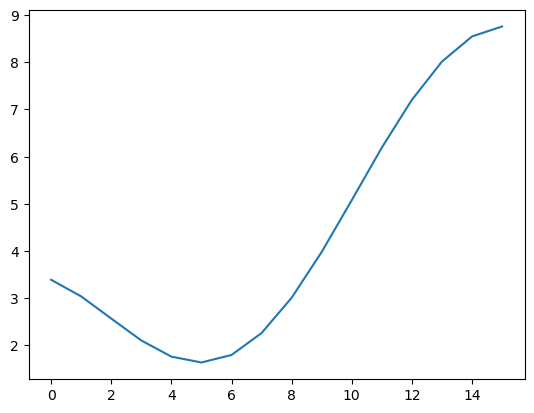

In [81]:
plt.plot(U_gen)

In [82]:
model.eval()
print(U_gen.shape)

(16,)


In [83]:
U_gen = torch.tensor(U_gen, dtype=torch.float32).unsqueeze(0)

In [84]:
x

array([[ 0. ,  0. ],
       [ 0. ,  0.2],
       [ 0. ,  0.4],
       ...,
       [ 1. ,  9.6],
       [ 1. ,  9.8],
       [ 1. , 10. ]])

In [85]:
x_train = torch.tensor(x, dtype=torch.float32)

In [86]:
U_gen.shape, x_train.shape

(torch.Size([1, 16]), torch.Size([816, 2]))

In [87]:
p = model(U_gen, x_train)

In [88]:
p=p.detach().numpy()

In [89]:
p.shape

(816, 1)

In [92]:
p_reshaped = p.reshape(mx, mt)

In [93]:
p_reshaped.shape

(16, 51)

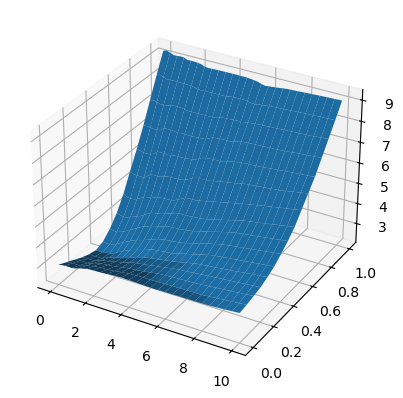

In [94]:
X, Y = np.meshgrid(y_gen, x_gen)
fig = plt.figure()
ax = fig.add_subplot(111, projection = '3d')
ax.plot_surface(X, Y, p_reshaped)

In [95]:
S = np.zeros((mx, mt, n))
S = UU
dx = abs(x_gen[0]-x_gen[1])
dt = abs(y_gen[0]-y_gen[1])
alpha = 0.01

for d in range(n):
    for t in range(1, mt-1):
        for i in range(1, mx-1):
            S[i, t+1, d] = UU[i, t, d] + alpha * (UU[i+1, t, d]-2*UU[i, t, d]+UU[i-1, t, d])*(dt/dx**2)

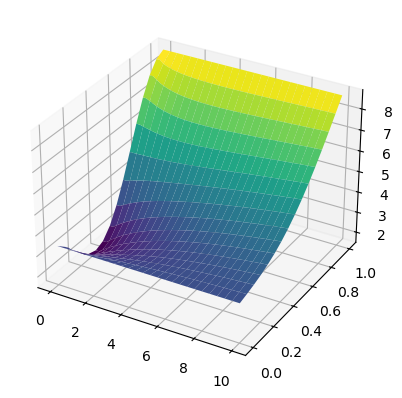

In [96]:
X, Y = np.meshgrid(y_gen, x_gen)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X,Y,S[:,:,target_result], cmap='viridis')

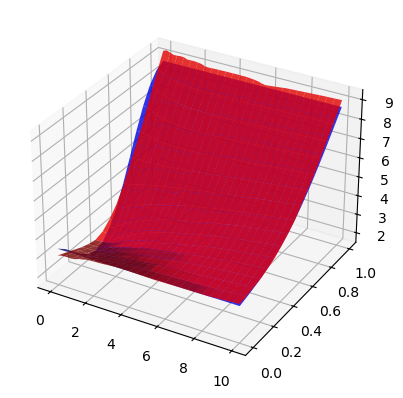

In [98]:
X, Y = np.meshgrid(y_gen, x_gen)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, S[:,:,target_result], alpha=0.8, color='b')
ax.plot_surface(X, Y, p_reshaped, alpha=0.8, color='r')

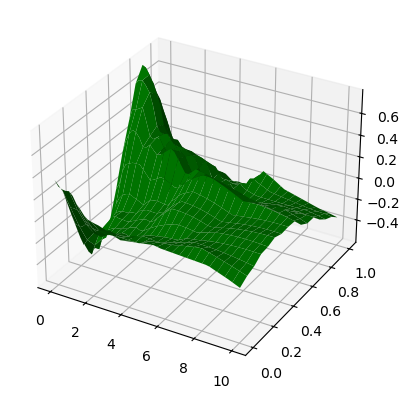

In [99]:
X, Y = np.meshgrid(y_gen, x_gen)
fig = plt.figure()
ax = fig.add_subplot(111, projection = '3d')
ax.plot_surface(X, Y, S[:,:,target_result]-p_reshaped, alpha=1, color='g')

### 